# Movie Recommendation System

## 1. Problem Framing

The objective is to predict the rating a user will assign to a movie they have not yet rated.

Model performance is evaluated using **Root Mean Squared Error (RMSE)**, with lower values indicating more accurate predictions.

The modelling process will progress from statistical baselines to collaborative filtering and feature-enriched approaches, with each improvement validated against a consistent evaluation framework.

## 2. Data Setup & Validation

In [1]:
from pathlib import Path
import pandas as pd
import time

DATA_DIR = Path("data")

ratings_dtypes = {
    "userId": "int32",
    "movieId": "int32",
    "rating": "float32",
    "timestamp": "int64",
}

start_time = time.perf_counter()

train_df = pd.read_csv(
    DATA_DIR / "train.csv",
    dtype=ratings_dtypes
)

test_df = pd.read_csv(
    DATA_DIR / "test.csv",
    dtype={
        "userId": "int32",
        "movieId": "int32",
    }
)

sample_submission_df = pd.read_csv(
    DATA_DIR / "sample_submission.csv"
)

load_seconds = time.perf_counter() - start_time

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Submission shape: {sample_submission_df.shape}")
print(f"Load time: {load_seconds:.1f}s")

Train shape: (10000038, 4)
Test shape: (5000019, 2)
Submission shape: (5000019, 2)
Load time: 16.0s


### Data Validation


In [2]:
print("TRAIN")
print(f"Rows: {len(train_df):,}")
print(f"Missing values: {train_df.isna().sum().sum():,}")
print(f"Duplicate user-movie pairs: {train_df.duplicated(['userId', 'movieId']).sum():,}")
print(f"Rating range: {train_df['rating'].min()} to {train_df['rating'].max()}")
print(f"Unique users: {train_df['userId'].nunique():,}")
print(f"Unique movies: {train_df['movieId'].nunique():,}")
print(f"Memory usage: {train_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nTEST")
print(f"Rows: {len(test_df):,}")
print(f"Missing values: {test_df.isna().sum().sum():,}")
print(f"Duplicate user-movie pairs: {test_df.duplicated(['userId', 'movieId']).sum():,}")
print(f"Unique users: {test_df['userId'].nunique():,}")
print(f"Unique movies: {test_df['movieId'].nunique():,}")

print("\nSUBMISSION")
print(f"Columns: {sample_submission_df.columns.tolist()}")
print(f"Rows match test: {len(sample_submission_df) == len(test_df)}")

print("\nDTYPES")
print(train_df.dtypes)

TRAIN
Rows: 10,000,038
Missing values: 0
Duplicate user-movie pairs: 0
Rating range: 0.5 to 5.0
Unique users: 162,541
Unique movies: 48,213
Memory usage: 200.0 MB

TEST
Rows: 5,000,019
Missing values: 0
Duplicate user-movie pairs: 0
Unique users: 162,350
Unique movies: 39,643

SUBMISSION
Columns: ['Id', 'rating']
Rows match test: True

DTYPES
userId         int32
movieId        int32
rating       float32
timestamp      int64
dtype: object


## 3. Exploratory Analysis

### 3.1 Rating Behaviour

In [3]:
rating_distribution = (
    train_df["rating"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

rating_distribution["percentage"] = (
    rating_distribution["count"] / len(train_df) * 100
)

display(rating_distribution)
# Summary statistics

print(f"Mean rating: {train_df['rating'].mean():.3f}")
print(f"Median rating: {train_df['rating'].median():.1f}")
print(f"Standard deviation: {train_df['rating'].std():.3f}")
print(f"Most common rating: {train_df['rating'].mode().iloc[0]:.1f}")

,count,percentage
rating,,
0.5,157571,1.575704
1.0,311213,3.112118
1.5,159731,1.597304
2.0,656821,6.568185
2.5,505578,5.055761
3.0,1959759,19.597516
3.5,1270642,12.706372
4.0,2652977,26.529669
4.5,880516,8.805127


Mean rating: 3.533
Median rating: 3.5
Standard deviation: 1.061
Most common rating: 4.0


Ratings are concentrated toward the upper end of the scale, with approximately 82% of observations at 3.0 or above. The mean rating is 3.53 and the modal rating is 4.0.

**Implication:** the global mean provides a meaningful baseline, but substantial residual variation remains for user- and movie-specific modelling.

### 3.2 User Behaviour


In [4]:
user_stats = (
    train_df
    .groupby("userId")["rating"]
    .agg(
        rating_count="count",
        mean_rating="mean"
    )
)

user_stats.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,rating_count,mean_rating
count,162541.000000,162541.000000
mean,61.523173,3.678923
std,107.410889,0.506977
min,1.000000,0.500000
25%,14.000000,3.376405
50%,28.000000,3.701493
75%,65.000000,4.000000
90%,142.000000,4.291667
95%,222.000000,4.454545
99%,491.600000,4.764706


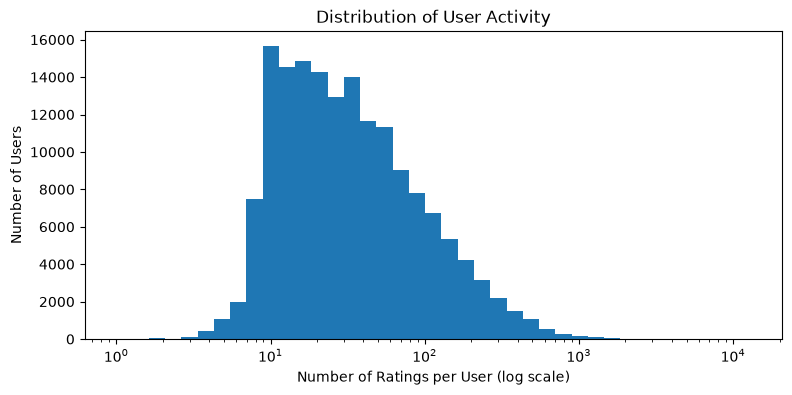

In [5]:
# Visualization of user activity distribution using a logarithmic scale.

import numpy as np
import matplotlib.pyplot as plt

bins = np.logspace(
    np.log10(user_stats["rating_count"].min()),
    np.log10(user_stats["rating_count"].max()),
    40
)

plt.figure(figsize=(9, 4))
plt.hist(user_stats["rating_count"], bins=bins)

plt.xscale("log")
plt.title("Distribution of User Activity")
plt.xlabel("Number of Ratings per User (log scale)")
plt.ylabel("Number of Users")
plt.show()

User activity is highly concentrated among lower-frequency raters, while a small minority of users contribute disproportionately large rating histories.

The log-scale distribution confirms substantial heterogeneity in interaction depth across users.

**Modelling implication:** user-specific estimates should be regularised, as behaviour inferred from sparse users is less reliable than behaviour inferred from highly active users.

### 3.3 Movie Behaviour


In [6]:
# Movie popularity and rating summary.
movie_stats = (
    train_df
    .groupby("movieId")["rating"]
    .agg(
        rating_count="count",
        mean_rating="mean"
    )
)

movie_stats.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,rating_count,mean_rating
count,48213.000000,48213.000000
mean,207.413727,3.100322
std,1092.768777,0.804220
min,1.000000,0.500000
25%,1.000000,2.700000
50%,4.000000,3.172881
75%,26.000000,3.583333
90%,252.000000,4.000000
95%,813.800000,4.166667
99%,4565.880000,5.000000


Movie interaction history is highly sparse and concentrated. Half of all movies have four or fewer ratings, while a small subset accounts for thousands of interactions.

Movie-level mean ratings are consequently unreliable for many titles; extreme averages often reflect very limited rating histories.

**Implication:** movie-specific effects require regularisation, with stronger shrinkage for rarely rated movies.

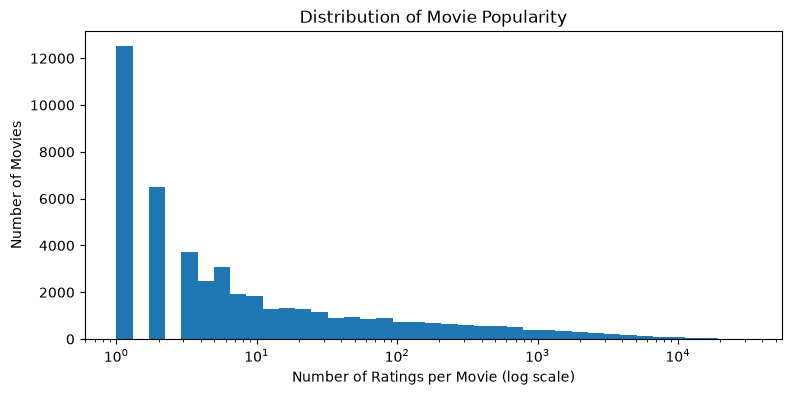

In [7]:
# Movie popularity distribution on a logarithmic scale.

bins = np.logspace(
    np.log10(movie_stats["rating_count"].min()),
    np.log10(movie_stats["rating_count"].max()),
    40
)

plt.figure(figsize=(9, 4))
plt.hist(movie_stats["rating_count"], bins=bins)

plt.xscale("log")
plt.title("Distribution of Movie Popularity")
plt.xlabel("Number of Ratings per Movie (log scale)")
plt.ylabel("Number of Movies")
plt.show()

### 3.4 Interaction Sparsity

In [8]:
# User–movie interaction density and sparsity.

n_users = train_df["userId"].nunique()
n_movies = train_df["movieId"].nunique()

possible_interactions = n_users * n_movies
observed_interactions = len(train_df)

density = observed_interactions / possible_interactions
sparsity = 1 - density

print(f"Users: {n_users:,}")
print(f"Movies: {n_movies:,}")
print(f"Possible interactions: {possible_interactions:,}")
print(f"Observed interactions: {observed_interactions:,}")
print(f"Density: {density:.4%}")
print(f"Sparsity: {sparsity:.4%}")

Users: 162,541
Movies: 48,213
Possible interactions: 7,836,589,233
Observed interactions: 10,000,038
Density: 0.1276%
Sparsity: 99.8724%


Only **0.13%** of all possible user–movie interactions are observed, leaving the interaction matrix **99.87% sparse**.

This confirms that most users have rated only a very small fraction of the available movies.

**Implication:** recommendation performance will depend on learning from sparse interaction patterns rather than relying on dense user histories, reinforcing the case for regularised collaborative filtering.

## 4. Validation Strategy


Model performance is evaluated on a fixed **20% holdout set**. Using the same split throughout the project ensures that all modelling and hyperparameter decisions are compared under identical conditions.

**RMSE** is used as the evaluation metric, with lower values indicating more accurate rating predictions.

In [9]:
from sklearn.model_selection import train_test_split

model_train, validation = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42
)

print(f"Model training rows: {len(model_train):,}")
print(f"Validation rows:     {len(validation):,}")

Model training rows: 8,000,030
Validation rows:     2,000,008


The validation split is now fixed for the remainder of the modelling process and will provide the common reference point for evaluating subsequent improvements.

## 5. Statistical Baselines

Before modelling user–movie interactions directly, simple statistical benchmarks establish how much predictive structure can be captured without latent preference modelling.

### 5.1 Global Mean

The simplest prediction assigns every interaction the average rating observed in the modelling training set. This provides a lower reference point for subsequent approaches.

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

global_mean = model_train["rating"].mean()

global_predictions = np.full(
    len(validation),
    global_mean,
    dtype=np.float32
)

global_rmse = np.sqrt(
    mean_squared_error(
        validation["rating"],
        global_predictions
    )
)

print(f"Global mean: {global_mean:.4f}")
print(f"Validation RMSE: {global_rmse:.4f}")

Global mean: 3.5335
Validation RMSE: 1.0609


The global-mean model produces a validation RMSE of **1.0609**.

This establishes the minimum reference point for the project: any useful recommender should improve on a prediction that ignores both user-specific and movie-specific behaviour.

### 5.2 User and Movie Biases

Users differ systematically in how generously they rate, while movies differ in their typical reception. A regularised bias model captures these two effects before modelling more complex user–movie interactions.

In [11]:
# Regularised user and movie bias estimation.

regularization = 10
n_iterations = 5

user_bias = pd.Series(
    0.0,
    index=model_train["userId"].unique()
)

movie_bias = pd.Series(
    0.0,
    index=model_train["movieId"].unique()
)

for _ in range(n_iterations):
    movie_effect = model_train["movieId"].map(movie_bias).fillna(0)

    user_residual = (
        model_train["rating"]
        - global_mean
        - movie_effect
    )

    user_bias = (
        user_residual.groupby(model_train["userId"]).sum()
        / (
            model_train.groupby("userId").size()
            + regularization
        )
    )

    user_effect = model_train["userId"].map(user_bias).fillna(0)

    movie_residual = (
        model_train["rating"]
        - global_mean
        - user_effect
    )

    movie_bias = (
        movie_residual.groupby(model_train["movieId"]).sum()
        / (
            model_train.groupby("movieId").size()
            + regularization
        )
    )

In [12]:
bias_predictions = (
    global_mean
    + validation["userId"].map(user_bias).fillna(0)
    + validation["movieId"].map(movie_bias).fillna(0)
)

bias_predictions = bias_predictions.clip(0.5, 5.0)

bias_rmse = np.sqrt(
    mean_squared_error(
        validation["rating"],
        bias_predictions
    )
)

print(f"Global mean RMSE: {global_rmse:.4f}")
print(f"Bias model RMSE:  {bias_rmse:.4f}")
print(f"RMSE improvement: {global_rmse - bias_rmse:.4f}")

Global mean RMSE: 1.0609
Bias model RMSE:  0.8655
RMSE improvement: 0.1954


The regularised user–movie bias model reduces validation RMSE from **1.0609** to **0.8655**, an improvement of **0.1954**.

This shows that a substantial share of rating variation is explained by systematic differences between users and movies. The remaining error suggests that additive biases alone are insufficient, motivating a model that can learn user–movie interaction patterns directly.



## 6. Collaborative Filtering

The statistical baselines capture broad user and movie effects, but they do not model how individual users interact with particular movies.

Collaborative filtering addresses this by learning preference patterns directly from the user–movie rating history.

### 6.1 SVD Recommender

SVD represents users and movies through latent factors while also accounting for user and movie biases. This allows the recommender to capture interaction patterns that cannot be explained by additive effects alone.

In [13]:
# Load the selected SVD configuration from the optimization artifacts.

from pathlib import Path
import json

BEST_CONFIG_PATH = Path(
    "artifacts/svd_tuning/best_svd_config.json"
)

with open(BEST_CONFIG_PATH, "r", encoding="utf-8") as f:
    best_config = json.load(f)

print("Selected SVD configuration:")
print(f"Factors:        {best_config['n_factors']}")
print(f"Epochs:         {best_config['n_epochs']}")
print(f"Learning rate:  {best_config['lr_all']}")
print(f"Regularization: {best_config['reg_all']}")
print(f"Validation RMSE:{best_config['rmse']:.6f}")

Selected SVD configuration:
Factors:        190
Epochs:         250
Learning rate:  0.002
Regularization: 0.06
Validation RMSE:0.807368


The selected configuration uses **190 latent factors**, **250 training epochs**, a learning rate of `0.002`, and regularization of `0.06`. This configuration achieved a validation RMSE of **0.807368** during optimization and is now used to reproduce the final validation model.

In [16]:
# Build the final training set using all available ratings.
from surprise import Dataset, Reader, SVD

reader = Reader(rating_scale=(0.5, 5.0))

full_data = Dataset.load_from_df(
    train_df[["userId", "movieId", "rating"]],
    reader
)

full_trainset = full_data.build_full_trainset()

print(f"Users:   {full_trainset.n_users:,}")
print(f"Movies:  {full_trainset.n_items:,}")
print(f"Ratings: {full_trainset.n_ratings:,}")

Users:   162,541
Movies:  48,213
Ratings: 10,000,038


In [17]:
# Train the selected SVD model on all available training ratings.

final_model = SVD(
    n_factors=best_config["n_factors"],
    n_epochs=best_config["n_epochs"],
    lr_all=best_config["lr_all"],
    reg_all=best_config["reg_all"],
    random_state=42,
    verbose=True
)

start = time.perf_counter()

final_model.fit(full_trainset)

final_training_minutes = (
    time.perf_counter() - start
) / 60

print(
    f"\nFinal training time: "
    f"{final_training_minutes:.2f} min"
)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
Processing epoch 40
Processing epoch 41
Processing epoch 42
Processing epoch 43
Processing epoch 44
Processing epoch 45
Processing epoch 46
Processing epoch 47
Processing epoch 48
Processing epoch 49
Processing

## 7. Final Predictions and Submission

The selected SVD model is retrained on the complete training dataset using the strongest validated configuration.

The final model is then used to predict ratings for every user–movie pair in the test set. Predictions are clipped to the valid rating range and written to `submission.csv` using the required submission structure.

In [19]:
# Generate test predictions and create the submission file.

test_predictions = np.fromiter(
    (
        final_model.predict(
            int(user_id),
            int(movie_id)
        ).est
        for user_id, movie_id in zip(
            test_df["userId"],
            test_df["movieId"]
        )
    ),
    dtype=np.float64,
    count=len(test_df)
)

test_predictions = np.clip(
    test_predictions,
    0.5,
    5.0
)

submission = sample_submission_df.copy()

submission["rating"] = test_predictions

submission.to_csv(
    "submission.csv",
    index=False
)

print(f"Predictions generated: {len(test_predictions):,}")
print(f"Submission shape: {submission.shape}")
print(f"Prediction range: {test_predictions.min():.3f} - {test_predictions.max():.3f}")

display(submission.head())

Predictions generated: 5,000,019
Submission shape: (5000019, 2)
Prediction range: 0.500 - 5.000


,Id,rating
0,1_2011,3.103434
1,1_4144,4.185226
2,1_5767,3.726099
3,1_6711,4.194624
4,1_7318,2.986793


## 8. Conclusion

This project developed an end-to-end collaborative filtering recommendation system for approximately **10 million movie ratings**.

The modelling process showed a clear progression in predictive performance. A global-mean baseline achieved an RMSE of **1.0609**, while regularised user and movie biases reduced the error to **0.8655**. Introducing SVD collaborative filtering further improved performance, with the final selected configuration achieving a validation RMSE of **0.807368**.

The final model achieved an RMSE of approximately **0.79** on the competition test set, placing **29th out of 454 participants** on the leaderboard.

The project demonstrates the complete recommendation-system workflow: large-scale data validation and analysis, baseline construction, collaborative filtering, controlled hyperparameter optimisation, validation-based model selection, full-data retraining, and generation of final test predictions.

Further improvements could explore richer interaction signals, additional item information, or more expressive recommendation architectures beyond standard SVD.